Saving winequality (1) (1) (1).csv to winequality (1) (1) (1) (3).csv
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  qual

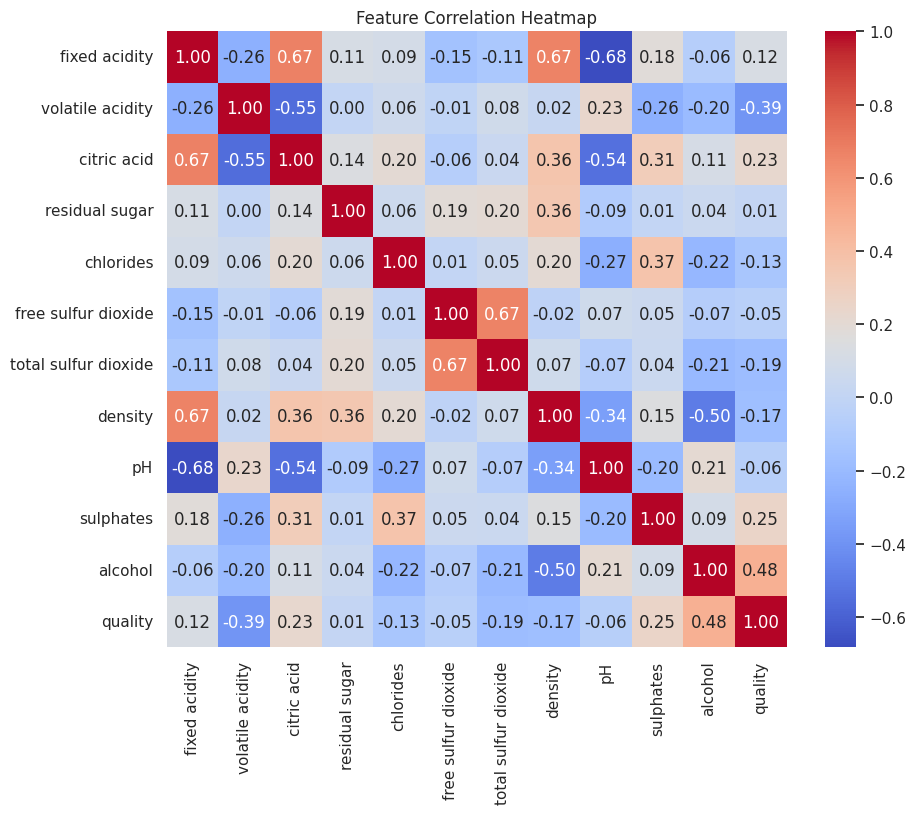


Correlation with quality:
 quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64
quality_label
0    1382
1     217
Name: count, dtype: int64


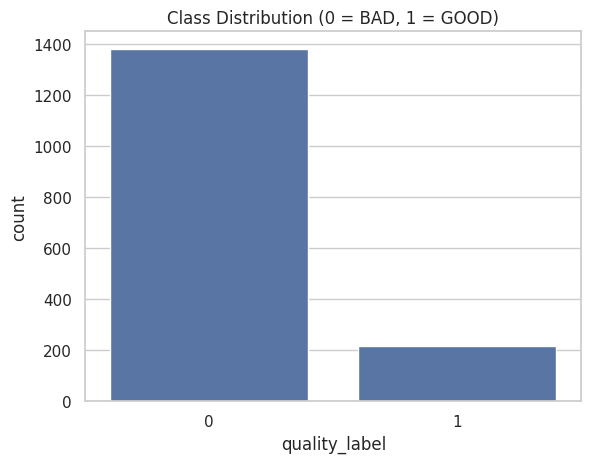


===== Logistic Regression (No Scaling) =====
Accuracy : 0.8938
Precision: 0.7368
Recall   : 0.3256
F1-score : 0.4516
Confusion Matrix:
 [[272   5]
 [ 29  14]]


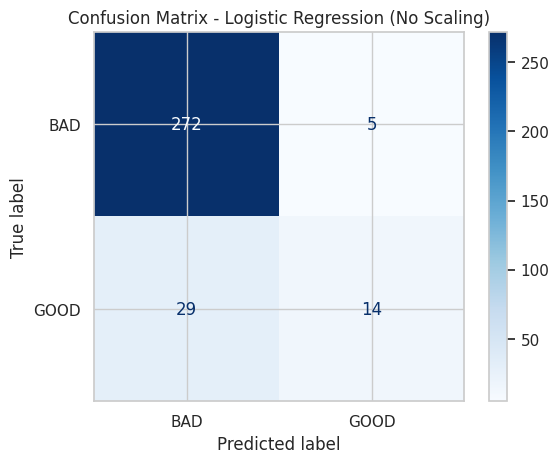


===== Logistic Regression (Scaled) =====
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848
Confusion Matrix:
 [[270   7]
 [ 27  16]]


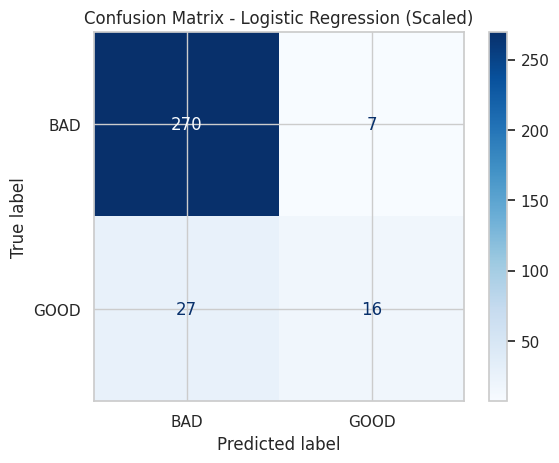


Comparison — Logistic Regression Before vs After Scaling:
                              model  accuracy  precision    recall        f1
0  Logistic Regression (No Scaling)   0.89375   0.736842  0.325581  0.451613
1      Logistic Regression (Scaled)   0.89375   0.695652  0.372093  0.484848

===== Logistic Regression =====
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848
Confusion Matrix:
 [[270   7]
 [ 27  16]]


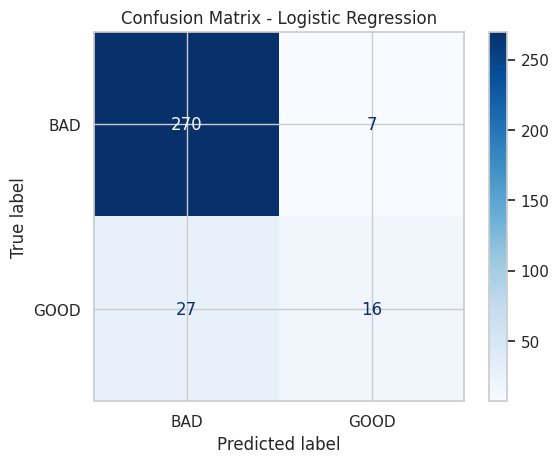


===== KNN =====
Accuracy : 0.8938
Precision: 0.6667
Recall   : 0.4186
F1-score : 0.5143
Confusion Matrix:
 [[268   9]
 [ 25  18]]


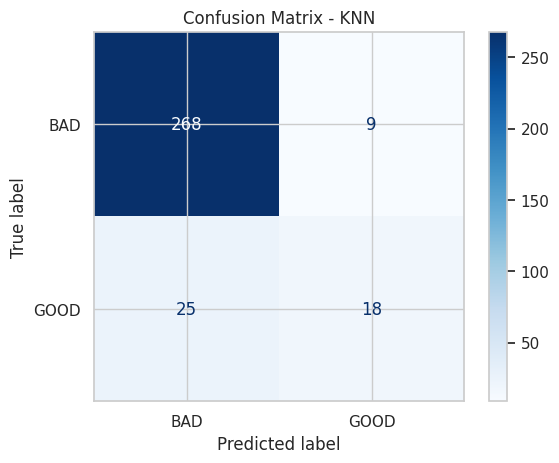


===== Decision Tree =====
Accuracy : 0.9000
Precision: 0.6170
Recall   : 0.6744
F1-score : 0.6444
Confusion Matrix:
 [[259  18]
 [ 14  29]]


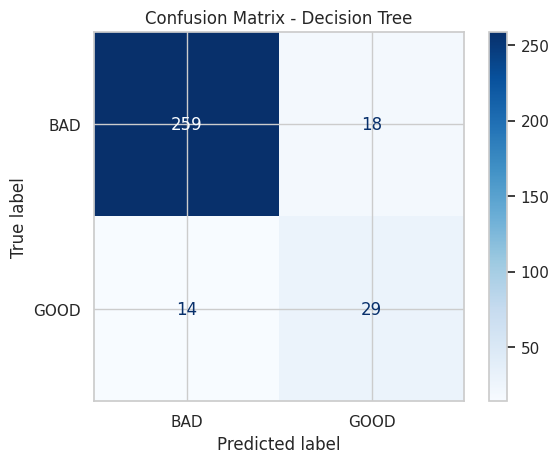


===== Model Comparison (sorted by F1-score) =====
                 model  accuracy  precision    recall        f1
2        Decision Tree   0.90000   0.617021  0.674419  0.644444
1                  KNN   0.89375   0.666667  0.418605  0.514286
0  Logistic Regression   0.89375   0.695652  0.372093  0.484848

Best performing model: Decision Tree
Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-score: 0.5254553665512569

===== Decision Tree (Tuned with GridSearchCV) =====
Accuracy : 0.9250
Precision: 0.7317
Recall   : 0.6977
F1-score : 0.7143
Confusion Matrix:
 [[266  11]
 [ 13  30]]


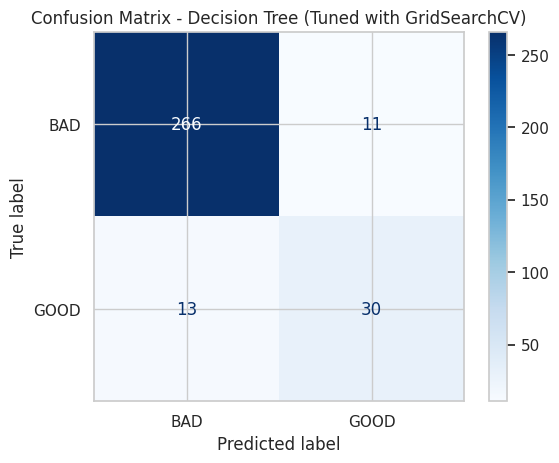

/tmp/ipykernel_1175/1444988549.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


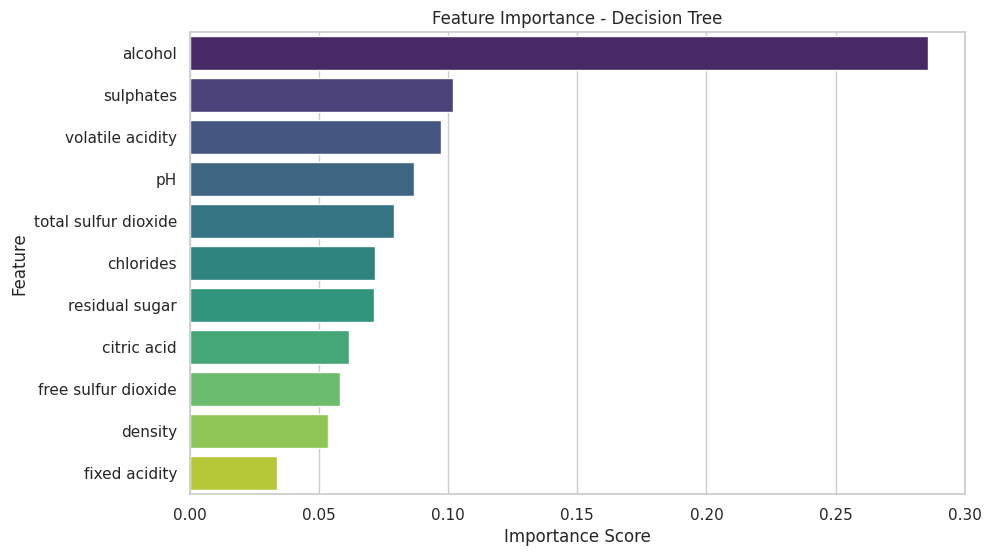


Feature Importances:
 alcohol                 0.285914
sulphates               0.101674
volatile acidity        0.097330
pH                      0.086588
total sulfur dioxide    0.078875
chlorides               0.071724
residual sugar          0.071398
citric acid             0.061351
free sulfur dioxide     0.058129
density                 0.053257
fixed acidity           0.033761
dtype: float64
FINAL MODEL SUMMARY
Algorithm Used : Decision Tree (Tuned with GridSearchCV)
Description    : A tree-based classifier that splits wine samples on
                 chemical properties (e.g. alcohol, sulphates) to
                 predict whether a wine is GOOD (>=7) or BAD (<7).
Accuracy       : 0.9250
Precision      : 0.7317
Recall         : 0.6977
F1-score       : 0.7143
Confusion Matrix:
[[266  11]
 [ 13  30]]


Enter the following details of the new wine sample:
  fixed acidity: 
  Please enter a valid number.
  fixed acidity: 
  Please enter a valid number.
  fixed acidity: 
  Please ente

('BAD', array([1., 0.]))

In [9]:
# ============================================================
# PROJECT 1: WINE QUALITY PREDICTION (Decision Tree Focus)
# Paste each "# --- Cell" section into a separate Colab cell
# ============================================================

# --- Cell 1: Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set(style="whitegrid")


# --- Cell 2: Load Dataset from YOUR file path ---
#
# OPTION A — Running LOCALLY (Jupyter/Anaconda/VS Code on your own PC):
# Use a raw string (r"...") so backslashes in the Windows path aren't
# misread as escape characters.
# FILE_PATH = r"C:\Users\luvku\Downloads\winequality (1) (1) (1).csv"
#
# OPTION B — Running in GOOGLE COLAB (cloud, can't see your PC's files):
# 1) Run this in a cell first, then choose your file from the upload dialog:
from google.colab import files
uploaded = files.upload()
# 2) Then set:
FILE_PATH = "winequality (1) (1) (1).csv"
#
# Uncomment ONE of the two lines above depending on where you're running this.

df = pd.read_csv(FILE_PATH)
# df = pd.read_csv(FILE_PATH, sep=";") # add sep=";" here if your CSV uses semicolons instead of commas

print(df.head())
print(df.info())
print(df.describe())


# --- Cell 3: Missing Values Check ---
print("Missing values per column:\n", df.isnull().sum())


# --- Cell 4: Correlation Analysis ---
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig('feature_correlation_heatmap.png') # Save plot to file
plt.show()

print("\nCorrelation with quality:\n", corr["quality"].sort_values(ascending=False))


# --- Cell 5: Create Binary Target ---
df["quality_label"] = df["quality"].apply(lambda q: 1 if q >= 7 else 0)

print(df["quality_label"].value_counts())
sns.countplot(x="quality_label", data=df)
plt.title("Class Distribution (0 = BAD, 1 = GOOD)")
plt.savefig('class_distribution.png') # Save plot to file
plt.show()


# --- Cell 6: Features and Target ---
FEATURE_COLUMNS = [c for c in df.columns if c not in ["quality", "quality_label"]]

X = df[FEATURE_COLUMNS]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# --- Cell 7: Helper function to evaluate any model ---
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model", plot=True):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    if plot:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BAD", "GOOD"])
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix - {name}")
        plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "confusion_matrix": cm}


# --- Cell 8: Logistic Regression WITHOUT Scaling ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
result_unscaled = evaluate_model(log_reg, X_train, X_test, y_train, y_test,
                                  "Logistic Regression (No Scaling)")


# --- Cell 9: Apply StandardScaler ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Cell 10: Logistic Regression WITH Scaling ---
log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
result_scaled = evaluate_model(log_reg_scaled, X_train_scaled, X_test_scaled,
                                y_train, y_test, "Logistic Regression (Scaled)")

print("\nComparison — Logistic Regression Before vs After Scaling:")
print(pd.DataFrame([result_unscaled, result_scaled]).drop(columns="confusion_matrix"))


# --- Cell 11: Compare Three Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []
for name, model in models.items():
    if name == "Decision Tree":
        res = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    else:
        res = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(res)

results_df = pd.DataFrame(results).drop(columns="confusion_matrix").sort_values(by="f1", ascending=False)
print("\n===== Model Comparison (sorted by F1-score) =====")
print(results_df)

best_model_name = results_df.iloc[0]["model"]
print(f"\nBest performing model: {best_model_name}")


# --- Cell 12: Hyperparameter Tuning on Decision Tree using GridSearchCV ---
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

best_dt = grid_search.best_estimator_


# --- Cell 13: Evaluate Tuned Decision Tree on Test Set (FINAL MODEL) ---
FINAL_MODEL_NAME = "Decision Tree (Tuned with GridSearchCV)"
final_result = evaluate_model(best_dt, X_train, X_test, y_train, y_test, FINAL_MODEL_NAME)


# --- Cell 14: Feature Importance Analysis ---
importances = pd.Series(best_dt.feature_importances_, index=FEATURE_COLUMNS)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.savefig('feature_importance.png') # Save plot to file
plt.show()

print("\nFeature Importances:\n", importances)


# --- Cell 15: FINAL MODEL SUMMARY (2-line description + metrics) ---
summary_content = "" # Initialize an empty string to build the summary
summary_content += "=" * 60 + "\n"
summary_content += "FINAL MODEL SUMMARY\n"
summary_content += "=" * 60 + "\n"
summary_content += f"Algorithm Used : {FINAL_MODEL_NAME}\n"
summary_content += f"Description    : A tree-based classifier that splits wine samples on\n"
summary_content += f"                 chemical properties (e.g. alcohol, sulphates) to\n"
summary_content += f"                 predict whether a wine is GOOD (>=7) or BAD (<7).\n"
summary_content += f"Accuracy       : {final_result['accuracy']:.4f}\n"
summary_content += f"Precision      : {final_result['precision']:.4f}\n"
summary_content += f"Recall         : {final_result['recall']:.4f}\n"
summary_content += f"F1-score       : {final_result['f1']:.4f}\n"
summary_content += "Confusion Matrix:\n"
summary_content += str(final_result["confusion_matrix"]) + "\n"
summary_content += "=" * 60 + "\n"

print(summary_content) # Keep print for immediate feedback in notebook

# Save the summary to a text file
with open('model_summary.txt', 'w') as f:
    f.write(summary_content)


# --- Cell 16: PREDICT ON NEW WINE DATA (User Input) ---
def predict_new_wine(model, feature_columns):
    """
    Prompts the user to enter values for each chemical property
    of a new wine sample, then predicts GOOD or BAD quality.
    """
    print("\nEnter the following details of the new wine sample:")
    input_values = {}
    for col in feature_columns:
        while True:
            try:
                val = float(input(f"  {col}: "))
                input_values[col] = val
                break
            except ValueError:
                print("  Please enter a valid number.")

    new_sample = pd.DataFrame([input_values], columns=feature_columns)
    prediction = model.predict(new_sample)[0]
    proba = model.predict_proba(new_sample)[0]

    label = "GOOD" if prediction == 1 else "BAD"
    confidence = proba[prediction] * 100

    print("\n----- Prediction Result -----")
    print(f"Predicted Quality : {label}")
    print(f"Confidence         : {confidence:.2f}%")
    print(f"Probability (BAD)  : {proba[0]*100:.2f}%")
    print(f"Probability (GOOD) : {proba[1]*100:.2f}%")
    print("------------------------------")

    return label, proba


# Run this cell to input a new wine sample and get a prediction:
predict_new_wine(best_dt, FEATURE_COLUMNS)


# --- Cell 17 (Optional): Predict on a Hardcoded Sample Instead of Typing ---
# sample = {
#     "fixed acidity": 7.4, "volatile acidity": 0.7, "citric acid": 0.0,
#     "residual sugar": 1.9, "chlorides": 0.076, "free sulfur dioxide": 11,
#     "total sulfur dioxide": 34, "density": 0.9978, "pH": 3.51,
#     "sulphates": 0.56, "alcohol": 9.4
# }
# new_df = pd.DataFrame([sample], columns=FEATURE_COLUMNS)
# pred = best_dt.predict(new_df)[0]
# print("GOOD" if pred == 1 else "BAD")
